## Etapa 1 - Importando Bibliotecas

In [2]:
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless
!pip install opencv-python==4.10.0.84

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
Found existing installation: opencv-contrib-python 4.14.0.94
Uninstalling opencv-contrib-python-4.14.0.94:
  Successfully uninstalled opencv-contrib-python-4.14.0.94
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 13.2 MB/s eta 0:00:00


In [3]:
import cv2
import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow
import zipfile

In [4]:
%tensorflow_version 2.x

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [5]:
import tensorflow
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
tensorflow.__version__

'2.20.0'

In [6]:
import matplotlib.pyplot as plt

In [7]:
!pip install tf_keras

## Etapa 2 - Conectando com o Drive e acessando os arquivos

In [8]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [9]:
path = "/content/gdrive/MyDrive/Colab Notebooks/Card 22/aula/Material.zip"
zip_object = zipfile.ZipFile(file=path, mode="r")
zip_object.extractall('./')
zip_object.close

<bound method ZipFile.close of <zipfile.ZipFile filename='/content/gdrive/MyDrive/Colab Notebooks/Card 22/aula/Material.zip' mode='r'>>

In [10]:
base_imgs = '/content/gdrive/MyDrive/Colab Notebooks/Card 22/aula/fer_images.zip'
zip_object = zipfile.ZipFile(file=base_imgs, mode="r")
zip_object.extractall('./')
zip_object.close

<bound method ZipFile.close of <zipfile.ZipFile filename='/content/gdrive/MyDrive/Colab Notebooks/Card 22/aula/fer_images.zip' mode='r'>>

## Etapa 3 - Acessando a base com fotos de expressoes faciais

In [11]:
data = pd.read_csv('fer2013/fer2013.csv') # carregamento do csv
data.tail()

,emotion,pixels,Usage
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest
35886,2,19 13 14 12 13 16 21 33 50 57 71 84 97 108 122...,PrivateTest


Text(0.5, 1.0, 'Imagens X Emoções')

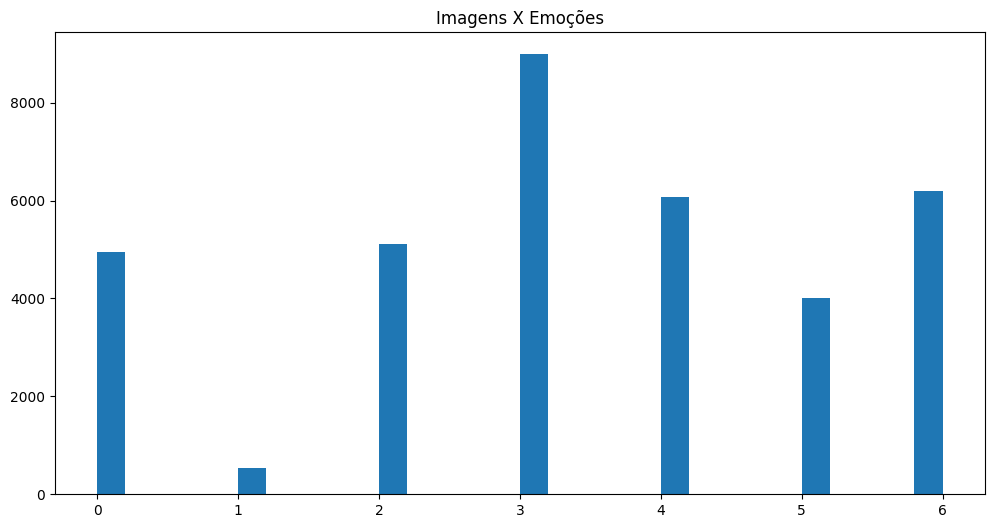

In [12]:
plt.figure(figsize=(12,6))
plt.hist(data['emotion'], bins=30) # 7 colunas
plt.title('Imagens X Emoções') # titulo

# classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Surprise', 'Neutral']

## Etapa 4 - Pré-processamento

In [13]:
pixels = data['pixels'].tolist() # convertendo para uma lista
pixels

Output hidden; open in https://colab.research.google.com to view.

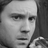

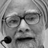

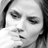

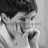

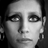

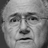

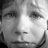

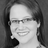

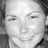

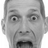

In [14]:
largura, altura = 48, 48 # dimensao
faces = []
amostras = 0
for pixel_sequence in pixels:
  face = [int(pixel) for pixel in pixel_sequence.split(' ')] # vai jogar cada um dos valores da string em pixel separa por espaço (' ')
  face = np.array(face).reshape(largura, altura) # transformando em um array e um reshape para 48x48
  faces.append(face) # colocando no formato do numpy array

  if (amostras < 10): # mostra as 10 primeiras imagens
    cv2_imshow(face)
  amostras += 1

In [15]:
print('Numero total de imagens no Dataset:', str(len(faces)))

Numero total de imagens no Dataset: 35887


In [16]:
faces = np.asarray(faces)

In [17]:
faces.shape

(35887, 48, 48)

In [18]:
faces = np.expand_dims(faces, -1) # expandir as dimensoes
faces.shape

(35887, 48, 48, 1)

In [19]:
def normalizar(x): # normalizando dados
  x = x.astype('float32')
  x = x / 255.0
  return x

In [20]:
faces = normalizar(faces)

In [21]:
faces[0]

array([[[0.27450982],
        [0.3137255 ],
        [0.32156864],
        ...,
        [0.20392157],
        [0.16862746],
        [0.16078432]],

       [[0.25490198],
        [0.23921569],
        [0.22745098],
        ...,
        [0.21960784],
        [0.20392157],
        [0.17254902]],

       [[0.19607843],
        [0.16862746],
        [0.21176471],
        ...,
        [0.19215687],
        [0.21960784],
        [0.18431373]],

       ...,

       [[0.35686275],
        [0.25490198],
        [0.16470589],
        ...,
        [0.28235295],
        [0.21960784],
        [0.16862746]],

       [[0.3019608 ],
        [0.32156864],
        [0.30980393],
        ...,
        [0.4117647 ],
        [0.27450982],
        [0.18039216]],

       [[0.3019608 ],
        [0.28235295],
        [0.32941177],
        ...,
        [0.41568628],
        [0.42745098],
        [0.32156864]]], dtype=float32)

In [22]:
emocoes = pd.get_dummies(data['emotion']).values

In [23]:
emocoes[0]

array([ True, False, False, False, False, False, False])

## Etapa 5 - Imports do Tensorflow/Keras

In [24]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from tensorflow.keras.models import model_from_json

## Etapa 6 - Dividir em conjuntos para treinamento e validação

In [25]:
x_train, x_test, y_train, y_test = train_test_split(faces, emocoes, test_size=0.1, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=41)

In [26]:
print('Numero de imagens no conjunto de treinamento: ',len(x_train))
print('Numero de imagens no conjunto de teste: ',len(x_test))
print('Numero de imagens no conjunto de validação: ',len(x_val))

Numero de imagens no conjunto de treinamento:  29068
Numero de imagens no conjunto de teste:  3589
Numero de imagens no conjunto de validação:  3230


In [27]:
# salvar a base de dados
np.save('mod_xtest', x_test)
np.save('mod_ytest', y_test)

## Etapa 7 - Arquitetura do modelo (CNN)

In [28]:
num_features = 64
num_labels = 7
batch_size = 64
epochs = 100
width, height = 48, 48

model = Sequential()

model.add(Conv2D(num_features, kernel_size=(3,3), activation='relu',
                 input_shape=(width, height, 1), data_format = 'channels_last',
                 kernel_regularizer=l2(0.01))) # primeira camada de convolução
model.add(Conv2D(num_features, kernel_size=(3,3), activation='relu', padding='same')) # segunda camada de convolução
model.add(BatchNormalization()) # normalização
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2))) # pooling
model.add(Dropout(0.5)) # dropout

model.add(Conv2D(2 * num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization()) # normalização
model.add(Conv2D(2 * num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization()) # normalização
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2))) # pooling
model.add(Dropout(0.5)) # dropout

model.add(Conv2D(2 * 2 * num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization()) # normalização
model.add(Conv2D(2 * 2 * num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization()) # normalização
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2))) # pooling
model.add(Dropout(0.5)) # dropout

model.add(Conv2D(2 * 2 * 2 * num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization()) # normalização
model.add(Conv2D(2 * 2 * 2 * num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization()) # normalização
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2))) # pooling
model.add(Dropout(0.5)) # dropout

model.add(Flatten()) # flatten

model.add(Dense(2 * 2 * 2 * num_features, activation='relu')) # camada Dense
model.add(Dropout(0.4)) # dropout
model.add(Dense(2 * 2 * num_features, activation='relu')) # camada Dense
model.add(Dropout(0.4)) # dropout
model.add(Dense(2 * num_features, activation='relu')) # camada Dense
model.add(Dropout(0.5)) # dropout

model.add(Dense(num_labels, activation='softmax'))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 23, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 23, 23, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 11, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 5, 5, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 5, 5, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 5, 5, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 5, 5, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,905,863 (22.53 MB)

 Trainable params: 5,902,151 (22.51 MB)

 Non-trainable params: 3,712 (14.50 KB)

## Etapa 8 - Compilando o Modelo

In [29]:
model.compile(loss='categorical_crossentropy',
              optimizer = Adam(learning_rate=0.001, beta_1=0.9,beta_2=0.999, epsilon=1e-7),
              metrics=['accuracy']) # configurando o compile
arquivo_modelo = 'modelo_01_expressoes.h5' # arquivo do modelo
arquivo_modelo_json = 'modelo_01_expressoes.json' # arquivo do modelo json
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.9, patience=3, verbose=1) # aplicar o reducer
early_stopper = EarlyStopping(monitor='val_loss', min_delta=0, patience=8, verbose=1, mode='auto') # aplicar o early stopper
checkpointer = ModelCheckpoint(arquivo_modelo, monitor='val_loss', verbose=1, save_best_only=True) # aplicar o checkpointer, salvando o modelo

## Salvando a arquitetura do modelo em um arquivo JSON

In [30]:
model_json = model.to_json() # salvando o modelo em um arquivo json
with open(arquivo_modelo_json, 'w') as json_file: # abrindo o arquivo para salvar
  json_file.write(model_json)

## Etapa 9 - Treinando o modelo

In [31]:
history = model.fit(np.array(x_train), np.array(y_train),
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(np.array(x_val), np.array(y_val)),
                    shuffle=True,
                    callbacks=[lr_reducer, checkpointer, early_stopper]) # iniciando o treinamento

Epoch 1/100
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.2029 - loss: 2.3053
Epoch 1: val_loss improved from None to 1.80965, saving model to modelo_01_expressoes.h5



Epoch 1: finished saving model to modelo_01_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 77s 104ms/step - accuracy: 0.2196 - loss: 1.9790 - val_accuracy: 0.2594 - val_loss: 1.8096 - learning_rate: 0.0010
Epoch 2/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2381 - loss: 1.8441
Epoch 2: val_loss improved from 1.80965 to 1.77982, saving model to modelo_01_expressoes.h5



Epoch 2: finished saving model to modelo_01_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.2438 - loss: 1.8362 - val_accuracy: 0.2594 - val_loss: 1.7798 - learning_rate: 0.0010
Epoch 3/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2531 - loss: 1.8083
Epoch 3: val_loss did not improve from 1.77982
455/455 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.2545 - loss: 1.8040 - val_accuracy: 0.2613 - val_loss: 1.8385 - learning_rate: 0.0010
Epoch 4/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2808 - loss: 1.7587
Epoch 4: val_loss improved from 1.77982 to 1.65648, saving model to modelo_01_expressoes.h5



Epoch 4: finished saving model to modelo_01_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.2982 - loss: 1.7336 - val_accuracy: 0.3430 - val_loss: 1.6565 - learning_rate: 0.0010
Epoch 5/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3399 - loss: 1.6584
Epoch 5: val_loss improved from 1.65648 to 1.49309, saving model to modelo_01_expressoes.h5



Epoch 5: finished saving model to modelo_01_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.3557 - loss: 1.6268 - val_accuracy: 0.3916 - val_loss: 1.4931 - learning_rate: 0.0010
Epoch 6/100
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3924 - loss: 1.5570
Epoch 6: val_loss did not improve from 1.49309
455/455 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.3971 - loss: 1.5426 - val_accuracy: 0.3579 - val_loss: 1.5811 - learning_rate: 0.0010
Epoch 7/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4073 - loss: 1.4964
Epoch 7: val_loss improved from 1.49309 to 1.38323, saving model to modelo_01_expressoes.h5


...


Epoch 21: finished saving model to modelo_01_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.6011 - loss: 1.0897 - val_accuracy: 0.6046 - val_loss: 1.0747 - learning_rate: 0.0010
Epoch 22/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6105 - loss: 1.0592
Epoch 22: val_loss improved from 1.07465 to 1.05947, saving model to modelo_01_expressoes.h5



Epoch 22: finished saving model to modelo_01_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.6068 - loss: 1.0712 - val_accuracy: 0.6099 - val_loss: 1.0595 - learning_rate: 0.0010
Epoch 23/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6272 - loss: 1.0271
Epoch 23: val_loss did not improve from 1.05947
455/455 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.6226 - loss: 1.0413 - val_accuracy: 0.6102 - val_loss: 1.0979 - learning_rate: 0.0010
Epoch 24/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6299 - loss: 1.0253
Epoch 24: val_loss did not improve from 1.05947
455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.6277 - loss: 1.0322 - val_accuracy: 0.5814 - val_loss: 1.1527 - learning_rate: 0.0010
Epoch 25/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6424 - loss: 0.9964
Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0009000000427477062.

Epoch 25: val_loss did not improve from 1.05947
455/455 ━━━━━━━━━━━━━━


Epoch 26: finished saving model to modelo_01_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.6426 - loss: 0.9821 - val_accuracy: 0.6198 - val_loss: 1.0505 - learning_rate: 9.0000e-04
Epoch 27/100
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6493 - loss: 0.9685
Epoch 27: val_loss did not improve from 1.05052
455/455 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.6521 - loss: 0.9642 - val_accuracy: 0.6167 - val_loss: 1.0658 - learning_rate: 9.0000e-04
Epoch 28/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6612 - loss: 0.9257
Epoch 28: val_loss did not improve from 1.05052
455/455 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.6564 - loss: 0.9448 - val_accuracy: 0.5780 - val_loss: 1.1540 - learning_rate: 9.0000e-04
Epoch 29/100
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6682 - loss: 0.9148
Epoch 29: val_loss improved from 1.05052 to 1.03714, saving model to modelo_01_expressoes.h5



Epoch 29: finished saving model to modelo_01_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.6666 - loss: 0.9215 - val_accuracy: 0.6238 - val_loss: 1.0371 - learning_rate: 9.0000e-04
Epoch 30/100
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6672 - loss: 0.9119
Epoch 30: val_loss did not improve from 1.03714
455/455 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.6687 - loss: 0.9140 - val_accuracy: 0.6155 - val_loss: 1.0524 - learning_rate: 9.0000e-04
Epoch 31/100
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6814 - loss: 0.8878
Epoch 31: val_loss did not improve from 1.03714
455/455 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.6765 - loss: 0.8949 - val_accuracy: 0.6260 - val_loss: 1.0591 - learning_rate: 9.0000e-04
Epoch 32/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6783 - loss: 0.8637
Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0008100000384729356.

Epoch 32: val_loss did not improve from 1.03714
455/455 ━━


Epoch 34: finished saving model to modelo_01_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.6963 - loss: 0.8360 - val_accuracy: 0.6334 - val_loss: 1.0175 - learning_rate: 8.1000e-04
Epoch 35/100
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7055 - loss: 0.8097
Epoch 35: val_loss did not improve from 1.01749
455/455 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.7040 - loss: 0.8148 - val_accuracy: 0.6356 - val_loss: 1.0859 - learning_rate: 8.1000e-04
Epoch 36/100
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7093 - loss: 0.8050
Epoch 36: val_loss did not improve from 1.01749
455/455 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.7093 - loss: 0.8058 - val_accuracy: 0.6300 - val_loss: 1.0797 - learning_rate: 8.1000e-04
Epoch 37/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7159 - loss: 0.7794
Epoch 37: ReduceLROnPlateau reducing learning rate to 0.0007290000503417104.

Epoch 37: val_loss did not improve from 1.01749
455/455 ━━

In [32]:
print(history.history) # mostra o historico dos resultados

{'accuracy': [0.21958854794502258, 0.2438076287508011, 0.2544722855091095, 0.29816293716430664, 0.35571762919425964, 0.39713773131370544, 0.41681572794914246, 0.43931472301483154, 0.4669395983219147, 0.4863767623901367, 0.4945300817489624, 0.5140360593795776, 0.5297234058380127, 0.5374294519424438, 0.5502958297729492, 0.5580019354820251, 0.5678409337997437, 0.5779895186424255, 0.5872436761856079, 0.5917847752571106, 0.6011077761650085, 0.6067841053009033, 0.6226434707641602, 0.6277349591255188, 0.6373331546783447, 0.6425966620445251, 0.6520572304725647, 0.6564263105392456, 0.6666437387466431, 0.6687422394752502, 0.6764827370643616, 0.6785812377929688, 0.6908972263336182, 0.6962639093399048, 0.7040044069290161, 0.7093023061752319, 0.7133273482322693, 0.7212398648262024, 0.7269161939620972, 0.7369616031646729, 0.7465254068374634, 0.7499312162399292], 'loss': [1.9790126085281372, 1.836200475692749, 1.803994059562683, 1.7336015701293945, 1.6267532110214233, 1.542603611946106, 1.48498201370

## Gerando o gráfico da melhora em cada etapa do treinamento

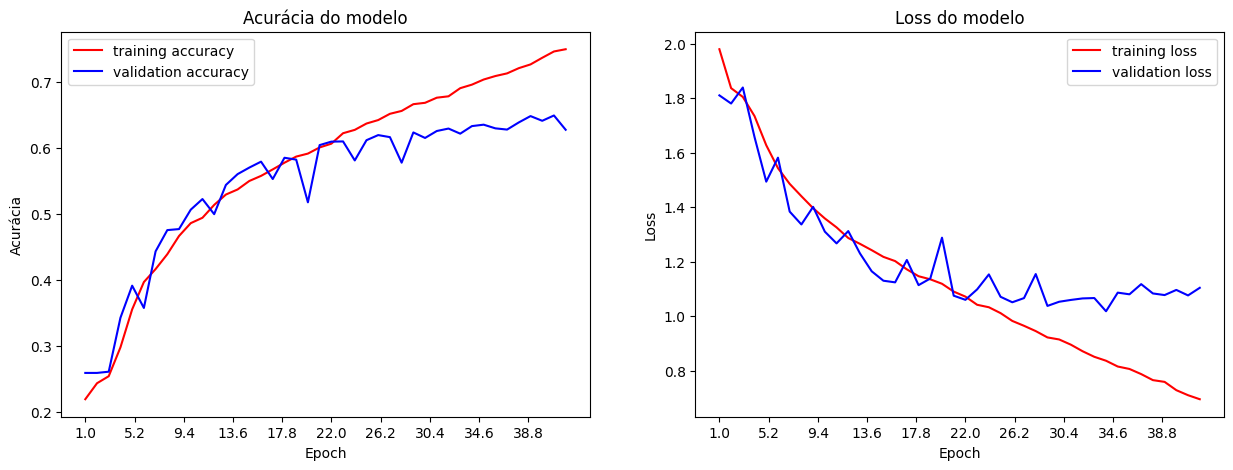

In [33]:
def plota_historico_modelo(historico_modelo):
  fig, axs = plt.subplots(1, 2, figsize=(15,5))
  axs[0].plot(range(1, len(historico_modelo.history['accuracy']) + 1), historico_modelo.history['accuracy'], 'r') # plot da acuracia
  axs[0].plot(range(1, len(historico_modelo.history['val_accuracy']) + 1), historico_modelo.history['val_accuracy'], 'b') # plot do val_accuracy
  axs[0].set_title('Acurácia do modelo') # titulo
  axs[0].set_ylabel('Acurácia') # eixo y
  axs[0].set_xlabel('Epoch') # eixo x
  axs[0].set_xticks(np.arange(1,len(historico_modelo.history['accuracy']) + 1,
        len(historico_modelo.history['accuracy']) / 10))
  axs[0].legend(['training accuracy', 'validation accuracy'], loc='best') # legenda

  axs[1].plot(range(1, len(historico_modelo.history['loss']) + 1), historico_modelo.history['loss'], 'r') # plot do loss
  axs[1].plot(range(1, len(historico_modelo.history['val_loss']) + 1), historico_modelo.history['val_loss'], 'b') # plot do val_loss
  axs[1].set_title('Loss do modelo') # titulo
  axs[1].set_ylabel('Loss') # eixo y
  axs[1].set_xlabel('Epoch') # eixo x
  axs[1].set_xticks(np.arange(1,len(historico_modelo.history['loss']) + 1,
        len(historico_modelo.history['loss']) / 10))
  axs[1].legend(['training loss', 'validation loss'], loc='best') # legenda
  fig.savefig('historico_modelo_mod01.png') # salvar a figura

plota_historico_modelo(history)

## Verificando a acurácia do modelo

In [34]:
scores = model.evaluate(np.array(x_test), np.array(y_test), batch_size=batch_size) # fazendo avaliação do modelo

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6233 - loss: 1.1925


In [35]:
scores

[1.1924800872802734, 0.623293399810791]

In [36]:
print('Acurácia: ' + str(scores[1]))
print('Erro: ' + str(scores[0]))

Acurácia: 0.623293399810791
Erro: 1.1924800872802734


## Carregamento dos dados para gerar a matriz de confusão

In [37]:
true_y = [] # recebe as respostas reais
pred_y = [] # recebe as respostas das previsoes
x = np.load('mod_xtest.npy') # carregando o x_test
y = np.load('mod_ytest.npy') # carregando o y_test

In [38]:
x[0]

array([[[0.5568628 ],
        [0.5803922 ],
        [0.59607846],
        ...,
        [0.3529412 ],
        [0.3529412 ],
        [0.3647059 ]],

       [[0.5568628 ],
        [0.5764706 ],
        [0.5921569 ],
        ...,
        [0.33333334],
        [0.36078432],
        [0.40392157]],

       [[0.5529412 ],
        [0.5686275 ],
        [0.5921569 ],
        ...,
        [0.3372549 ],
        [0.32156864],
        [0.37254903]],

       ...,

       [[0.0627451 ],
        [0.08235294],
        [0.07058824],
        ...,
        [0.08235294],
        [0.09019608],
        [0.11372549]],

       [[0.05490196],
        [0.0627451 ],
        [0.05490196],
        ...,
        [0.07450981],
        [0.07843138],
        [0.09803922]],

       [[0.04705882],
        [0.04705882],
        [0.04705882],
        ...,
        [0.06666667],
        [0.07450981],
        [0.09411765]]], dtype=float32)

In [39]:
y[0] # valor da emoção

array([False, False, False,  True, False, False, False])

In [40]:
json_file = open(arquivo_modelo_json, 'r') # abrindo o arquivo json para fazer a leitura
loaded_model_json = json_file.read() # lendo o arquivo json
json_file.close() # liberar a memoria

In [41]:
loaded_model = model_from_json(loaded_model_json) # carregando o modelo
loaded_model.load_weights(arquivo_modelo) # carregando os pesos

In [42]:
y_pred = loaded_model.predict(x) # fazendo a predição

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step


In [43]:
y_pred[0] # 7 probabilidades, aquele que tiver o maior valor é a classe que pertence a emoção

array([0.05432699, 0.00132876, 0.06316421, 0.50554365, 0.11082947,
       0.03987093, 0.22493601], dtype=float32)

In [44]:
yp = y_pred.tolist() # transformar para uma lista(previsao)
yt = y.tolist() # transformar para uma lista(respostas reais)
count = 0

In [45]:
len(y)

3589

In [46]:
for i in range(len(y)):
  yy = max(yp[i]) # pegando o maior valor da probabilidade do yp
  yyt = max(yt[i]) # pegando o maior valor da probabilidade do yt
  pred_y.append(yp[i].index(yy)) # fazendo associação
  true_y.append(yt[i].index(yyt)) # fazendo associação
  if (yp[i].index(yy) == yt[1].index(yyt)):
    count += 1

acc = (count / len(y)) * 100

In [47]:
print('Acurácia no conjunto de teste: ', str(acc))

Acurácia no conjunto de teste:  19.67121760936194


In [48]:
np.save('truey_mod01', true_y)
np.save('predy_mod01', pred_y)

## Gerando a matriz de confusão

In [49]:
from  sklearn.metrics import confusion_matrix

In [50]:
# carregando os modelos
y_true = np.load('truey_mod01.npy')
y_pred = np.load('predy_mod01.npy')

In [51]:
cm = confusion_matrix(y_true, y_pred) # criando a variavel da matriz de confusao
expressoes = ['Raiva', 'Nojo', 'Medo', 'Feliz', 'Triste', 'Surpreso', 'Neutro']
titulo = 'Matriz de confusão'
print(cm)

[[270   1  54  22  70  13  68]
 [ 27  11   6   1   5   1   1]
 [ 80   2 195  19 136  53  60]
 [ 27   1  13 734  33  32  41]
 [ 72   0  32  24 337   1 122]
 [ 11   0  49  23  10 304  17]
 [ 39   1  15  52 101   6 397]]


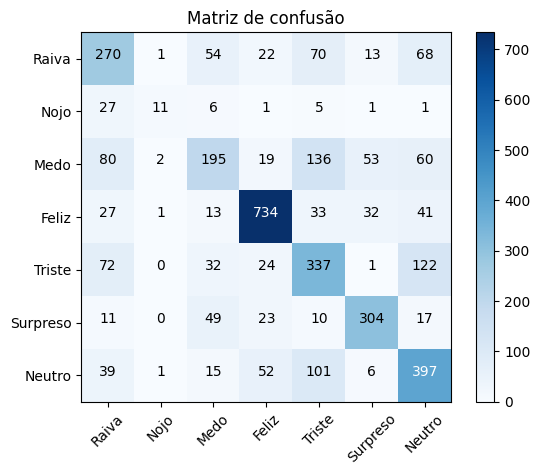

In [52]:
import itertools
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues) # criando a imagem de matriz
plt.title(titulo) # titulo
plt.colorbar() # barra de cores
tick_marks = np.arange(len(expressoes)) # tamamho de acordo com a quantidade de emocoes
plt.xticks(tick_marks, expressoes, rotation=45) # eixo x(classes)
plt.yticks(tick_marks, expressoes); # eixo y
fmt = 'd'
thresh = cm.max() / 2. # buscar o maior valor da matriz de confusão e dividir por 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])): # percoreendo a matriz acessando a linhas e as colunas
   plt.text(j,i, format(cm[i,j], fmt), horizontalalignment='center',color='white' if cm[i,j] > thresh else 'black') # preenchimento com texto na matriz
plt.ylabel('Classificação correta')
plt.xlabel('Predição')
plt.savefig('matriz_confusao_mod01.png') # salvar a figura

## Testando modelo

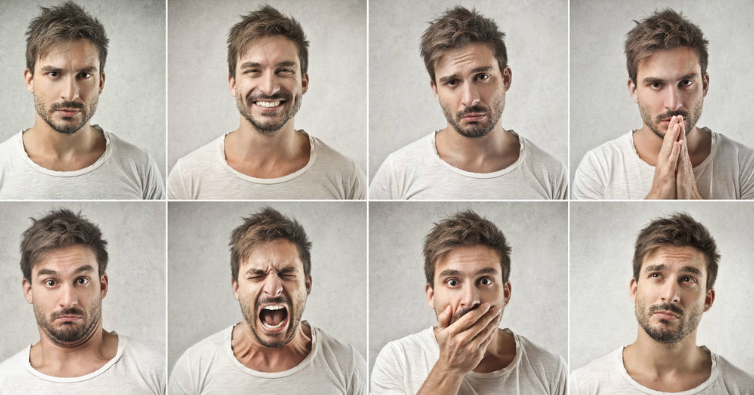

In [53]:
imagem = cv2.imread('Material/testes/teste02.jpg') # leitura da imagem
cv2_imshow(imagem) # mostra a imagem

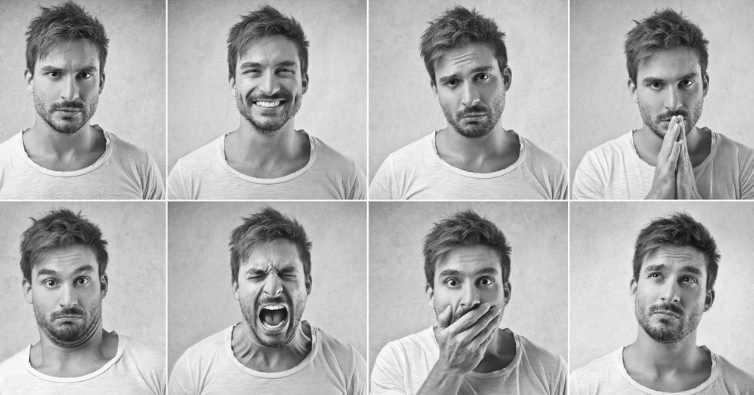

In [60]:
original = imagem.copy() # copia a imagem
gray = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY) # imagem cinza
cv2_imshow(gray) # mostra a imagem cinza

In [61]:
face_cascade = cv2.CascadeClassifier('Material/haarcascade_frontalface_default.xml') # carregando o classificador
faces = face_cascade.detectMultiScale(gray, 1.1, 3) # detecção da face

In [62]:
faces

array([[224,  35,  90,  90],
       [625,  49,  91,  91],
       [ 23,  41,  92,  92],
       [420,  43,  97,  97],
       [420, 242,  97,  97],
       [ 18, 243,  98,  98],
       [229, 242,  85,  85],
       [627, 241,  91,  91]], dtype=int32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


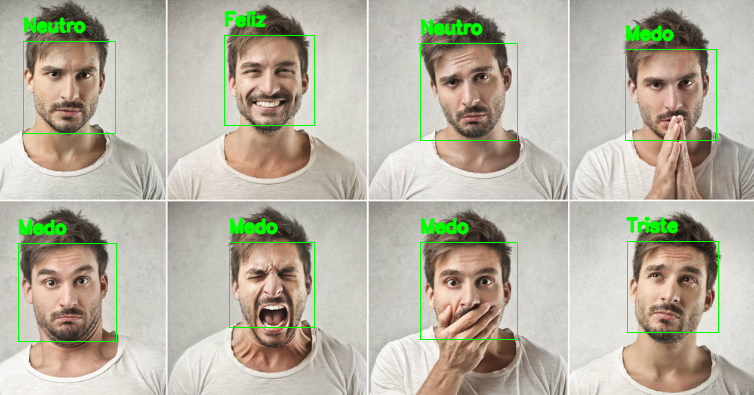

In [63]:
for(x,y,w,h) in faces:
  cv2.rectangle(original, (x,y), (x+w, y+h), (0,255,0), 1)
  roi_gray = gray[y:y+h, x:x+w]
  roi_gray = roi_gray.astype('float') / 255.0 # transformando em float, depois dividindo para ficar 0 e 1
  cropped_img = np.expand_dims(np.expand_dims(cv2.resize(roi_gray, (48,48)), -1), 0) # expandindo a dimensao
  prediction = loaded_model.predict(cropped_img)[0] # fazendo a predição
  cv2.putText(original, expressoes[int(np.argmax(prediction))], (x,y -10),
              cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2, cv2.LINE_AA)
cv2_imshow(original)